In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas
import PIL
import requests
import seaborn as sns

In [1]:
import requests

# Toronto Open Data is stored in a CKAN instance. It's APIs are documented here:
# https://docs.ckan.org/en/latest/api/

# To hit our API, you'll be making requests to:
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"

# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
url = base_url + "/api/3/action/package_show"
params = { "id": "traffic-counts-cycling"}
package = requests.get(url, params = params).json()

# To get resource data:
for idx, resource in enumerate(package["result"]["resources"]):

       # To get metadata for non datastore_active resources:
       if not resource["datastore_active"]:
           url = base_url + "/api/3/action/resource_show?id=" + resource["id"]
           resource_metadata = requests.get(url).json()
           print(resource_metadata)
           # From here, you can use the "url" attribute to download this file


{'help': 'https://ckan0.cf.opendata.inter.prod-toronto.ca/api/3/action/help_show?name=resource_show', 'success': True, 'result': {'cache_last_updated': None, 'cache_url': None, 'created': '2019-09-19T13:42:08.581153', 'datastore_active': False, 'format': 'ZIP', 'hash': '', 'id': 'd3b16e16-8ec5-4801-9038-912f986e675a', 'is_datastore_cache_file': False, 'is_preview': False, 'last_modified': None, 'metadata_modified': '2022-03-10T22:01:33.734716', 'mimetype': 'application/zip', 'mimetype_inner': None, 'name': 'volumes_atr_cyclists_shortterm.csv.zip', 'package_id': '1050c7c5-54a3-4be2-ab75-971d640973bd', 'position': 0, 'resource_type': None, 'revision_id': '6f685fc1-c682-4640-891a-0699993291c4', 'size': None, 'state': 'active', 'url': 'https://www.toronto.ca/data/transportation/opendata/volumes_atr_cyclists_shortterm.csv.zip', 'url_type': None}}
{'help': 'https://ckan0.cf.opendata.inter.prod-toronto.ca/api/3/action/help_show?name=resource_show', 'success': True, 'result': {'cache_last_upda

In [2]:
import pandas as pd

rows = []
for r in package["result"]["resources"]:
    rows.append({
        "name": r.get("name"),
        "format": r.get("format"),
        "datastore_active": r.get("datastore_active"),
        "url": r.get("url"),
    })

resources_df = pd.DataFrame(rows).sort_values(["format", "name"], na_position="last")
display(resources_df)   # in Jupyter
# or: print(resources_df.to_string(index=False))  # in terminal


,name,format,datastore_active,url
3,Traffic Counts - Cycling Readme,TXT,False,https://ckan0.cf.opendata.inter.prod-toronto.c...
1,volumes_atr_cyclists_permanent.csv.zip,ZIP,False,https://www.toronto.ca/data/transportation/ope...
2,volumes_atr_cyclists_permanent_daily.csv.zip,ZIP,False,https://www.toronto.ca/data/transportation/ope...
0,volumes_atr_cyclists_shortterm.csv.zip,ZIP,False,https://www.toronto.ca/data/transportation/ope...


In [3]:
import io, zipfile
import requests
import pandas as pd

# from your table output
zip_url = "https://www.toronto.ca/data/transportation/opendata/volumes_atr_cyclists_permanent_daily.csv.zip"

r = requests.get(zip_url, timeout=120)
r.raise_for_status()

with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    print("Files inside zip:", z.namelist())
    csv_name = next(n for n in z.namelist() if n.lower().endswith(".csv"))
    with z.open(csv_name) as f:
        df = pd.read_csv(f)

display(df.head())
print(df.shape)
print(df.columns)


Files inside zip: ['volumes_atr_cyclists_permanent_daily.csv']


,centreline_id,direction,location,class_type,dt,volume_daily
0,10923449,Nortbound,SHERBOURNE ST N/B N OF WELLESLEY ST E,Cyclists,2015-09-30,1417
1,10923449,Nortbound,SHERBOURNE ST N/B N OF WELLESLEY ST E,Cyclists,2015-09-29,897
2,10923449,Nortbound,SHERBOURNE ST N/B N OF WELLESLEY ST E,Cyclists,2015-09-28,827
3,10923449,Nortbound,SHERBOURNE ST N/B N OF WELLESLEY ST E,Cyclists,2015-09-27,921
4,10923449,Nortbound,SHERBOURNE ST N/B N OF WELLESLEY ST E,Cyclists,2015-09-26,827


(1034, 6)
Index(['centreline_id', 'direction', 'location', 'class_type', 'dt',
       'volume_daily'],
      dtype='object')


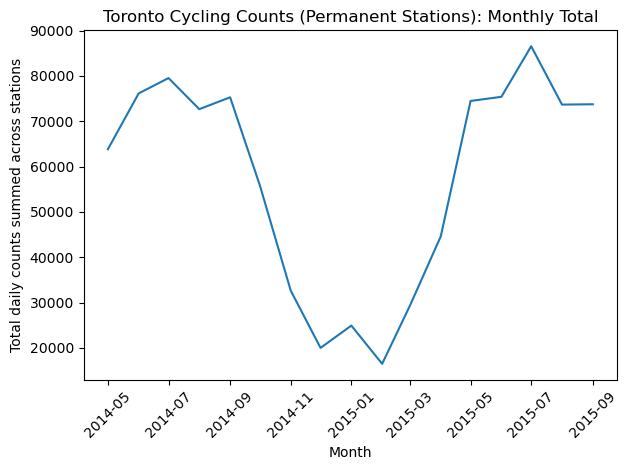

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df = df.dropna(subset=["dt"])

monthly = (
    df.assign(month=df["dt"].dt.to_period("M").dt.to_timestamp())
      .groupby("month", as_index=False)["volume_daily"].sum()
      .sort_values("month")
)

plt.figure()
plt.plot(monthly["month"], monthly["volume_daily"])
plt.title("Toronto Cycling Counts (Permanent Stations): Monthly Total")
plt.xlabel("Month")
plt.ylabel("Total daily counts summed across stations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


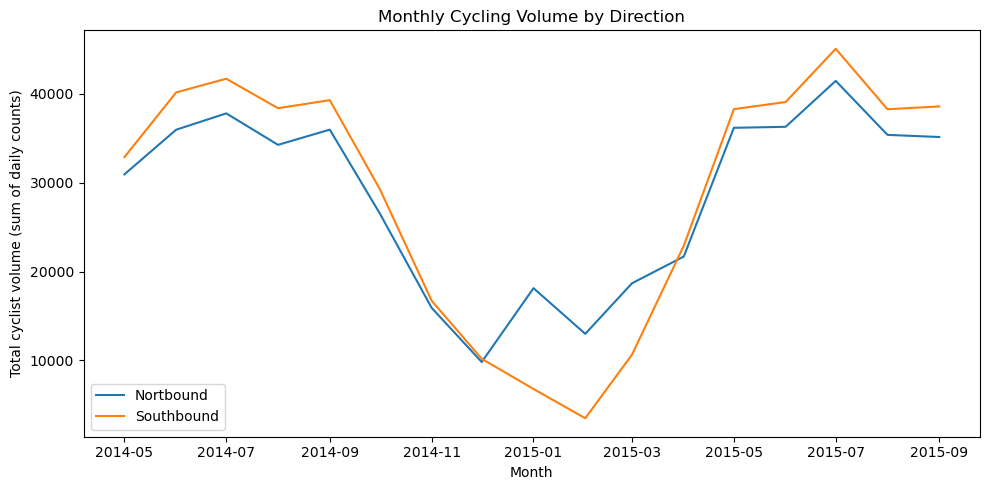

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df["dt"] = pd.to_datetime(df["dt"], errors="coerce")
df = df.dropna(subset=["dt"])

# monthly sums per direction
monthly_dir = (
    df.assign(month=df["dt"].dt.to_period("M").dt.to_timestamp())
      .groupby(["month", "direction"], as_index=False)["volume_daily"]
      .sum()
      .sort_values("month")
)

plt.figure(figsize=(10,5))
for d, sub in monthly_dir.groupby("direction"):
    plt.plot(sub["month"], sub["volume_daily"], label=d)

plt.title("Monthly Cycling Volume by Direction")
plt.xlabel("Month")
plt.ylabel("Total cyclist volume (sum of daily counts)")
plt.legend()
plt.tight_layout()
plt.show()
